# **HW2**



**AI Collaboration Disclaimer:**

Gemini 3.6 Flash was used on this assignment to help with the syntax for the figure plotting in parts 10 and 12.

I have reviewed the code in these parts before submission.


In [53]:
#imports given
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
import numpy as np

1.

In [40]:
concrete_data = pd.read_excel("/content/Concrete_Data.xls") #read data from spreadsheet
concrete_data.head()#print first few rows


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


2.

In [41]:
concrete_data = concrete_data.rename(columns={'Concrete compressive strength(MPa, megapascals) ': 'Strength'})
concrete_data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


3. Correlation Matrix


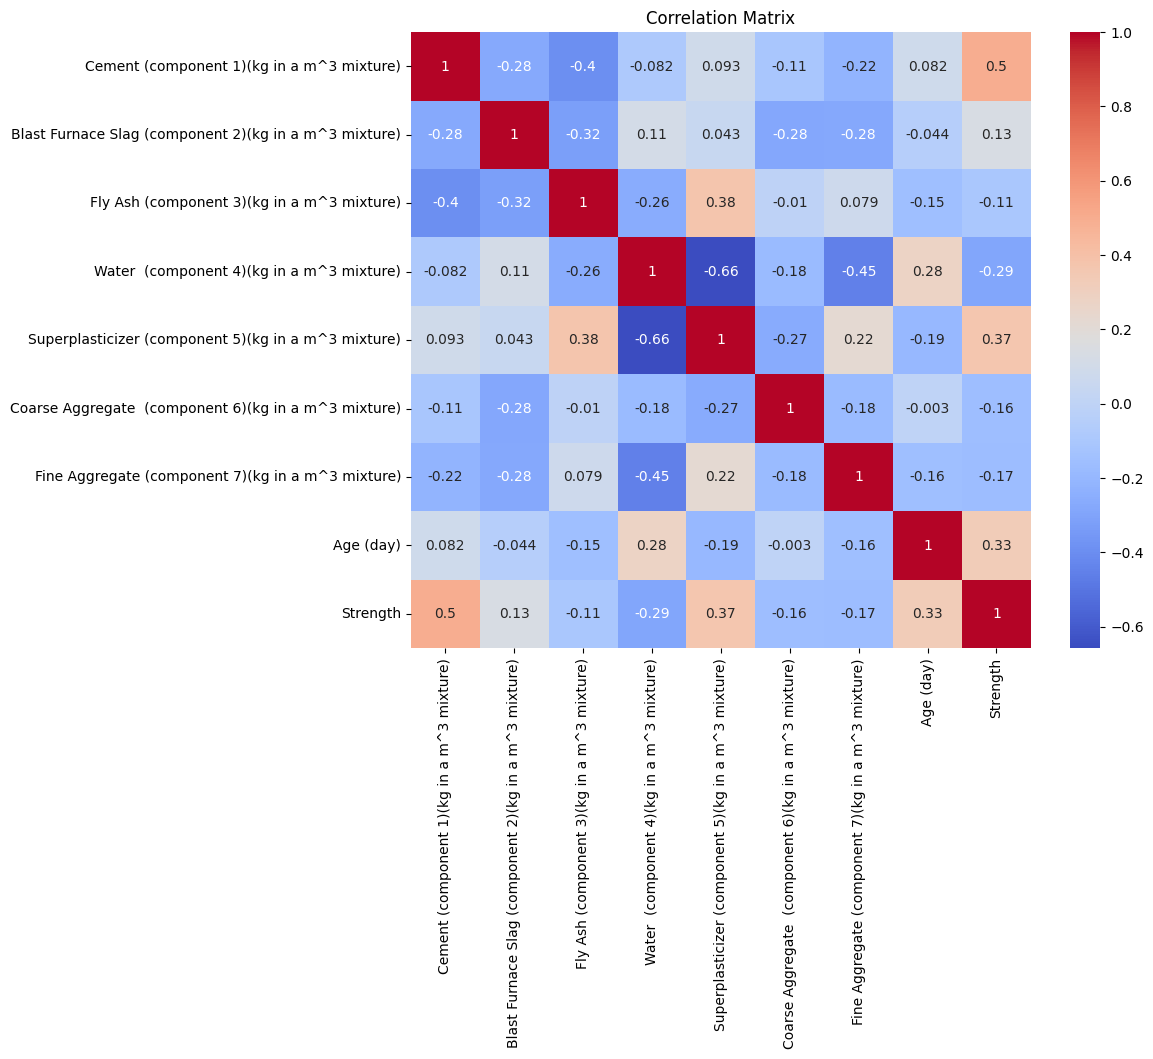

In [42]:
corr = concrete_data.corr(); #generate correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2g")#gemini assisted
plt.title("Correlation Matrix")
plt.show()

Explaination:

              There is a positive correlation between Cement and Strength

              There is a small negative correlation between Water and Strength


4.

In [43]:
#seperate data from target feature
X_train, X_test, y_train, y_test = train_test_split(
    concrete_data.drop(columns=['Strength']),
    concrete_data['Strength'],
    test_size=0.2,#make 20% of the dataset be the test set
)


5.

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)#define the scale based on the dataset minus the class column

X_test_scaled = scaler.fit_transform(X_test)

6.

In [45]:
clf = LinearRegression()
clf.fit(X_train_scaled, y_train)

# test_x_poly = poly.fit_transform(test_x)
test_y_lr = clf.predict(X_test_scaled)



7.



In [46]:
tree = DecisionTreeRegressor(max_depth=5) # Adjust max_depth to control complexity
tree.fit(X_train_scaled, y_train)

test_y_dt = tree.predict(X_test_scaled)

8.

In [47]:
svr = SVR(kernel='rbf')
# or kernel='poly' for polynomial kernel
svr.fit(X_train_scaled, y_train)

# test_x_poly = poly.fit_transform(test_x)
test_y_svr = svr.predict(X_test_scaled)




9.

In [48]:

print("Linear Regression MSE: %.2f" % np.mean((test_y_lr - y_test) ** 2))
print("Linear Regression R2: %.2f" % r2_score(y_test, test_y_lr) )

print("Decision Tree MSE: %.2f" % np.mean((test_y_dt - y_test) ** 2))
print("Decision Tree R2: %.2f" % r2_score(y_test, test_y_dt))

print("SVR MSE: %.2f" % np.mean((test_y_svr - y_test) ** 2))
print("SVR R2: %.2f" % r2_score(y_test, test_y_svr) )

Linear Regression MSE: 114.45
Linear Regression R2: 0.49
Decision Tree MSE: 72.91
Decision Tree R2: 0.68
SVR MSE: 91.50
SVR R2: 0.60


10.

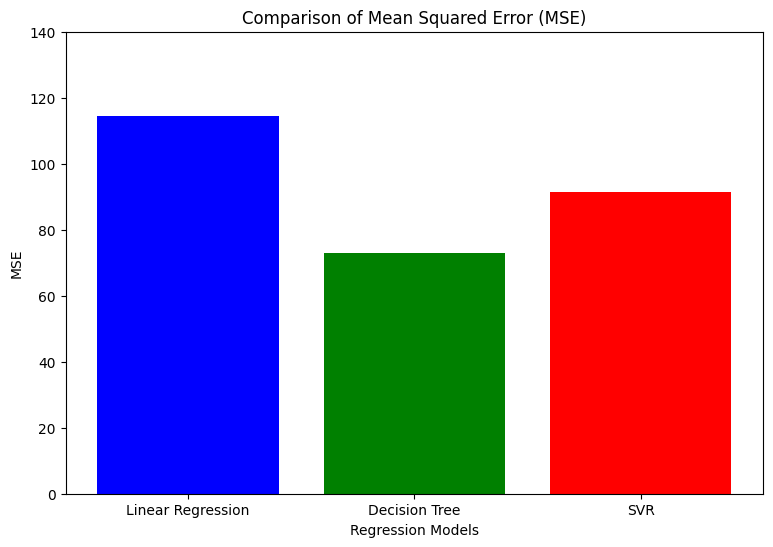

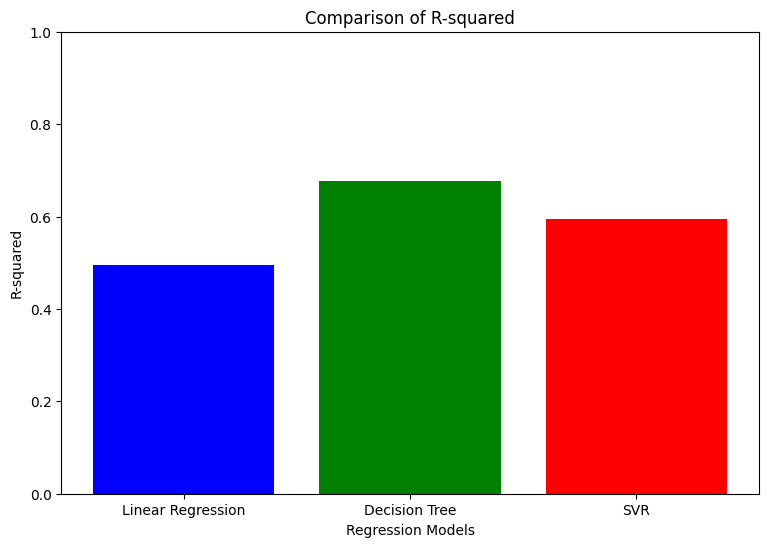

In [49]:
import matplotlib.pyplot as plt

# Define models and their corresponding MSE values
models = ['Linear Regression', 'Decision Tree', 'SVR']
mse_values = [np.mean((test_y_lr - y_test) ** 2), np.mean((test_y_dt - y_test) ** 2), np.mean((test_y_svr - y_test) ** 2)]  # Replace with your actual model MSE results

# Set figure size
plt.figure(figsize=(9, 6))

# Create bar plot with custom colors matching the image
plt.bar(models, mse_values, color=['blue', 'green', 'red'])

# Set plot title and axis labels
plt.title('Comparison of Mean Squared Error (MSE)')
plt.xlabel('Regression Models')
plt.ylabel('MSE')

# Set y-axis limits to match the range (0 to 100)
plt.ylim(0, 140)

# Display the plot
plt.show()

import matplotlib.pyplot as plt

# Define models and their corresponding R-s values
models = ['Linear Regression', 'Decision Tree', 'SVR']
mse_values = [r2_score(y_test, test_y_lr), r2_score(y_test, test_y_dt), r2_score(y_test, test_y_svr)]  # Replace with your actual model MSE results

# Set figure size
plt.figure(figsize=(9, 6))

# Create bar plot with custom colors matching the image
plt.bar(models, mse_values, color=['blue', 'green', 'red'])

# Set plot title and axis labels
plt.title('Comparison of R-squared')
plt.xlabel('Regression Models')
plt.ylabel('R-squared')

# Set y-axis limits to match the range (0 to 100)
plt.ylim(0, 1)

# Display the plot
plt.show()

11.

LR and SVR both have a high MSE and low R-squared score. This means that they arent very good a predicting accuratly. Conversly, DT has a low MSe and high R-squared score, meaning that it can predict with higher accuracy than the other two models.

These results suggest using DT for this dataset.

12.

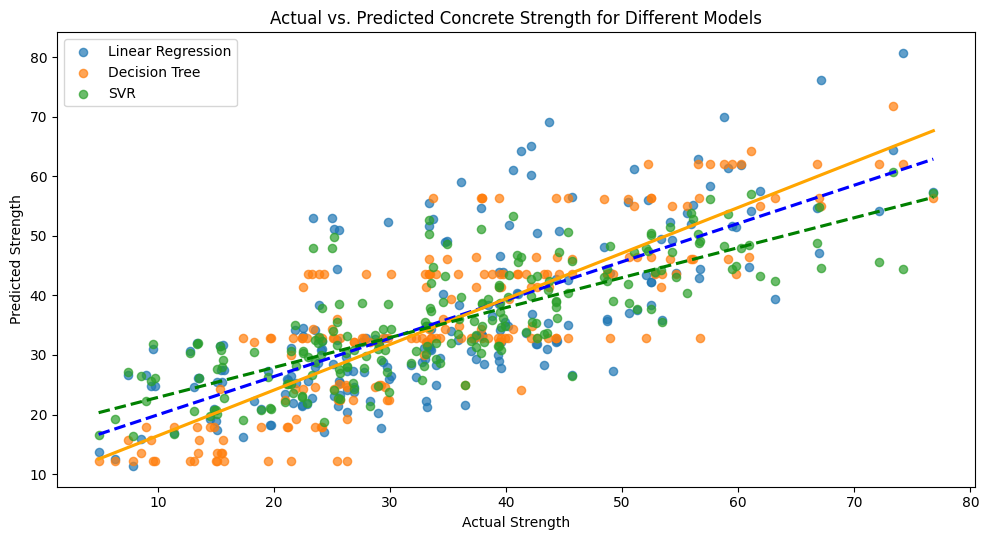

In [51]:
#Actual values
y_actual = y_test

#Plot Actual vs. Predicted
plt.figure(figsize=(10, 5.5))

sns.regplot(
    x=y_actual,
    y=test_y_lr,
    label="Linear Regression",
    scatter_kws={"alpha": 0.7, "s": 35},
    line_kws={"color": "blue", "linestyle": "--"},
    ci=None,
)

sns.regplot(
    x=y_actual,
    y=test_y_dt,
    label="Decision Tree",
    scatter_kws={"alpha": 0.7, "s": 35},
    line_kws={"color": "orange", "linestyle": "-"},
    ci=None,
)

sns.regplot(
    x=y_actual,
    y=test_y_svr,
    label="SVR",
    scatter_kws={"alpha": 0.7, "s": 35},
    line_kws={"color": "green", "linestyle": "--"},
    ci=None,
)

plt.title("Actual vs. Predicted Concrete Strength for Different Models")
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

13.

Explaination: the goal of the above plot is to show how the differnt modles perform across the rang of datapoints. A good model will have a 1:1 relationship between its x and y vaules for each point. which will producae a line consisatn with y = x.

lookiung at the graph, it can be observed that both SVR and LR overestimate the output on lower values and underestimate at higher values.

DT is the closest to the target, performing well at the low, middle, and high ranges.